In [1]:
# !pip install langgraph-checkpoint-sqlite

In [2]:
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.checkpoint.memory import InMemorySaver
import sqlite3

In [3]:
# create db
conn = sqlite3.connect(database = 'chatbot.db', check_same_thread = False)

# checkpointer

# store in sqlite
checkpointer = SqliteSaver(conn=conn)

# in memory storage
# checkpointer = InMemorySaver()

In [4]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage
from dotenv import load_dotenv

# import for reducer
from operator import add 
from typing import TypedDict, Annotated

# import for memory
# from langgraph.checkpoint.memory import InMemorySaver


In [5]:
llm = ChatGoogleGenerativeAI(
    model = "gemini-3.1-flash-lite",
    temperature=0
)


In [6]:
class StateSchema(TypedDict):
    messages: Annotated[list[BaseMessage], add]

In [7]:
def llm_chat(state: StateSchema):

    # get all the previous chat messages from current
    msgs = state["messages"]

    # send all the chat messages of current thread to llm
    resp = llm.invoke(msgs)

    return { "messages": [resp] }

In [8]:
graph = StateGraph(StateSchema)

graph.add_node("llm_chat", llm_chat)


graph.add_edge(START, "llm_chat")
graph.add_edge("llm_chat", END)



# compile flow with memory 
chatbot = graph.compile(checkpointer=checkpointer)

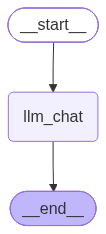

In [9]:
chatbot

In [10]:
config = {
    "configurable": {
        "thread_id": "user-1"
    }
}

In [11]:
while True:
    msg = input("You: ").strip()

    if not msg:
        continue

    if msg.lower() in ["quit", "bye", "exit"]:
        break

    human_message = HumanMessage(content=msg)

    resp = chatbot.invoke(
        {"messages": [human_message]},
        config
    )

    print(resp)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


{'messages': [HumanMessage(content='hello', additional_kwargs={}, response_metadata={}), AIMessage(content=[{'type': 'text', 'text': 'Hello! How can I help you today?', 'extras': {'signature': 'EnEKbwERTTIPBJ9lXpXvyU+Prdqx4FjPIs3F7TOacP8+0BHgeqCaW6yyl+P3Jvz/UMlaL9cnj8b2WKna+LnIp+DlBTYxQzv9GbZeTxLCnrtwrDB/b2xA8uN8Ah9irtrBuWWSnFw4cCeK+G4TZZZgO6DM0g=='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a00b0a-8e12-70b2-93b2-375a75e2ad84-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2, 'output_tokens': 9, 'total_tokens': 11, 'input_token_details': {'cache_read': 0}}), HumanMessage(content='my name is bhavin', additional_kwargs={}, response_metadata={}), AIMessage(content=[{'type': 'text', 'text': "It's nice to meet you, Bhavin! How are you doing today? Is there anything I can help you with?", 'extras': {'signature': 'EnEKbwERTTIPBGzE2v

In [12]:
def retrieve_all_threads():
    checkpointer_gen = checkpointer.list(None)
    all_threads = list(set(cp.config["configurable"]["thread_id"] for cp in checkpointer_gen))
    return all_threads

# get the list of threads
retrieve_all_threads()

['user-2', 'user-1', 'thread-1']